In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("datasets/features_dataset.csv")

In [3]:
df.shape

(336749, 55)

In [4]:
df_corr = df.drop(columns=["URL","File_Extension","Suffix"])

In [5]:
df_corr["Label"] = df_corr["Label"].map({
    "Phishing":1,
    "Legitimate":0
})


In [6]:
corr_matrix = df_corr.corr()

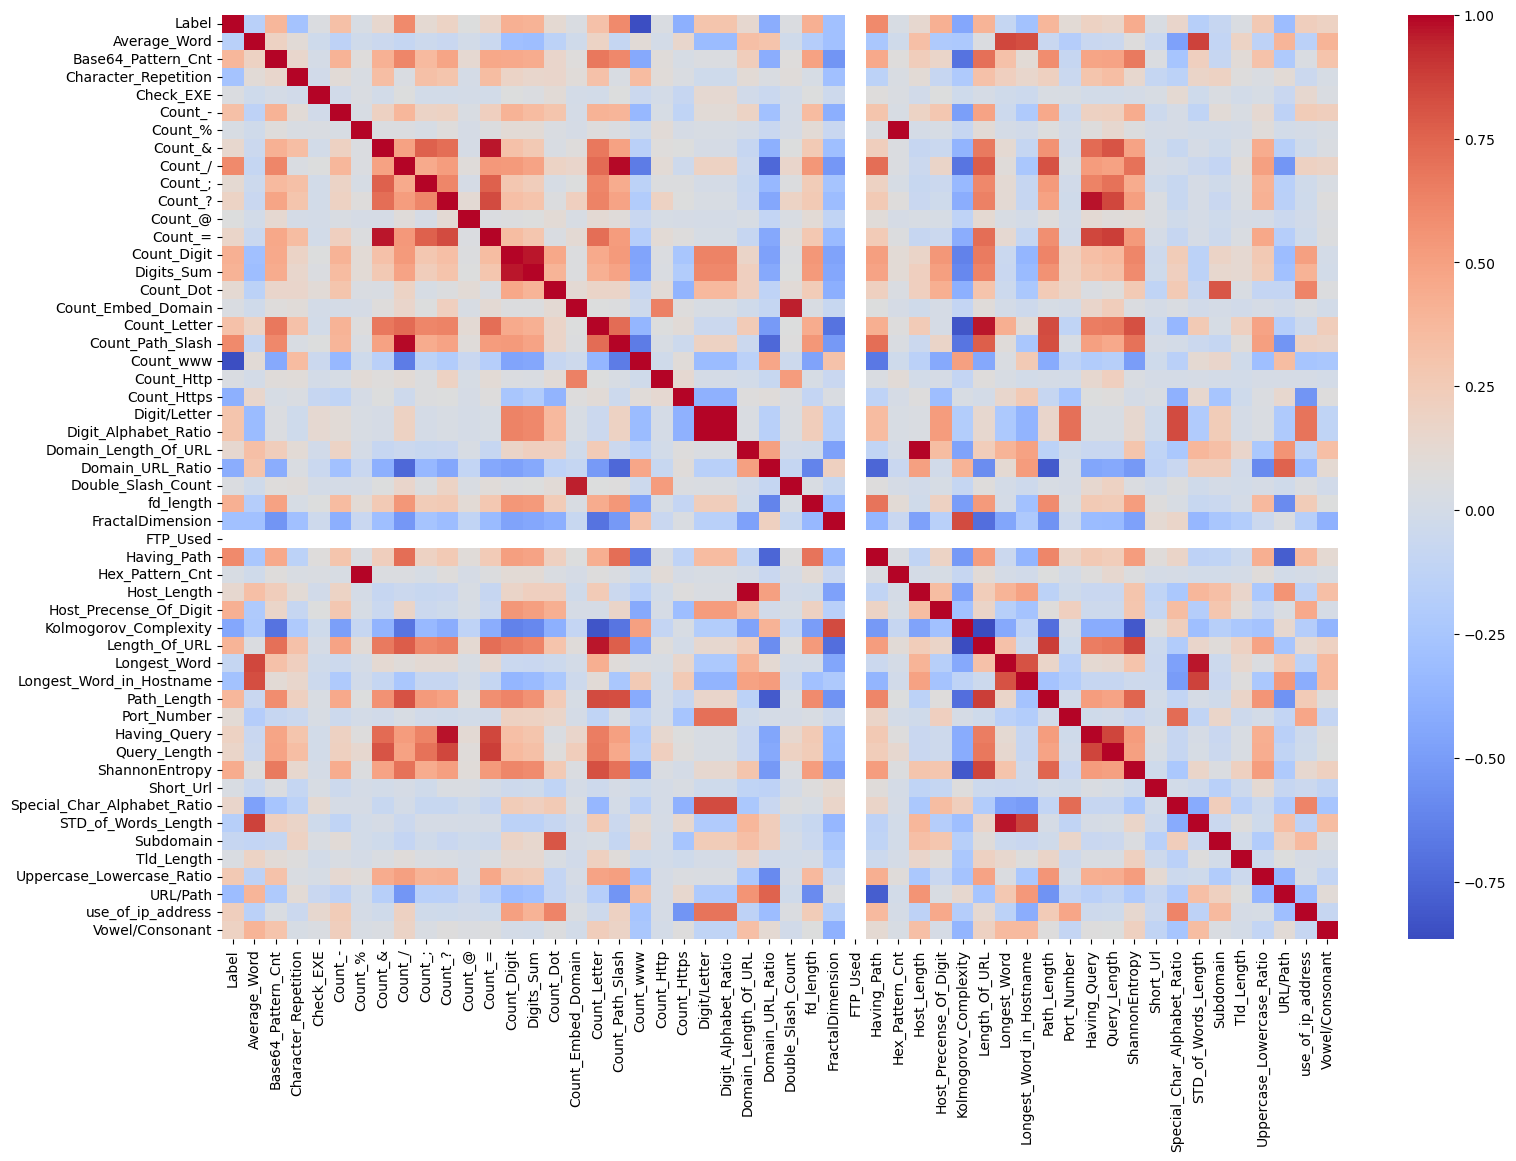

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18,12))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.show()

In [8]:
corr_matrix

,Label,Average_Word,Base64_Pattern_Cnt,Character_Repetition,Check_EXE,Count_-,Count_%,Count_&,Count_/,Count_;,...,ShannonEntropy,Short_Url,Special_Char_Alphabet_Ratio,STD_of_Words_Length,Subdomain,Tld_Length,Uppercase_Lowercase_Ratio,URL/Path,use_of_ip_address,Vowel/Consonant
Label,1.000000,-0.158944,0.386489,-0.274269,0.045445,0.329082,0.029694,0.140918,0.599700,0.121874,...,0.440388,0.033377,0.158212,-0.166074,-0.082451,0.043853,0.264537,-0.318123,0.222449,0.197252
Average_Word,-0.158944,1.000000,0.197923,0.103632,-0.027955,-0.132201,-0.027021,-0.055699,-0.092351,-0.042159,...,0.067316,-0.061129,-0.476367,0.868279,-0.106550,0.190996,-0.130460,0.387902,-0.144899,0.400786
Base64_Pattern_Cnt,0.386489,0.197923,1.000000,0.152557,0.003267,0.407007,0.080635,0.411973,0.618162,0.361361,...,0.665850,0.045407,-0.260116,0.214928,-0.078856,0.099219,0.314815,-0.213863,0.042828,0.303811
Character_Repetition,-0.274269,0.103632,0.152557,1.000000,-0.017338,0.103086,0.033301,0.338718,0.043766,0.322426,...,0.143068,-0.089880,-0.143052,0.172881,0.192151,0.067843,0.040207,0.105019,-0.053357,0.019665
Check_EXE,0.045445,-0.027955,0.003267,-0.017338,1.000000,-0.012969,0.040135,-0.006996,0.063671,-0.006050,...,0.002367,0.030612,0.124319,-0.031975,0.044919,-0.009611,0.020620,-0.066240,0.138387,0.041839
Count_-,0.329082,-0.132201,0.407007,0.103086,-0.012969,1.000000,0.024375,0.198501,0.386075,0.182705,...,0.444822,-0.044145,0.009881,-0.120849,0.099306,0.032836,0.131659,-0.130241,0.244809,0.222928
Count_%,0.029694,-0.027021,0.080635,0.033301,0.040135,0.024375,1.000000,0.046538,0.049591,0.019616,...,0.058221,0.002502,0.013642,-0.006284,-0.007028,0.004893,0.081979,-0.010140,0.001877,0.023862
Count_&,0.140918,-0.055699,0.411973,0.338718,-0.006996,0.198501,0.046538,1.000000,0.497103,0.762589,...,0.488032,-0.009551,-0.076598,0.010859,-0.030072,0.043381,0.440371,-0.173070,-0.027361,0.042733
Count_/,0.599700,-0.092351,0.618162,0.043766,0.063671,0.386075,0.049591,0.497103,1.000000,0.451080,...,0.695909,0.014186,-0.002349,-0.054392,-0.093532,0.085493,0.502831,-0.534396,0.202783,0.182215
Count_;,0.121874,-0.042159,0.361361,0.322426,-0.006050,0.182705,0.019616,0.762589,0.451080,1.000000,...,0.439038,-0.024215,-0.072837,0.014281,-0.024699,0.039493,0.409311,-0.161566,-0.024139,0.036479


In [9]:
import numpy as np

corr_matrix = df_corr.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_features = [column for column in upper.columns if any(upper[column] > 0.90)]

high_corr_features

['Count_=',
 'Digits_Sum',
 'Count_Path_Slash',
 'Digit_Alphabet_Ratio',
 'Double_Slash_Count',
 'Hex_Pattern_Cnt',
 'Host_Length',
 'Length_Of_URL',
 'Having_Query',
 'STD_of_Words_Length']

In [10]:
df_reduced = df_corr.drop(columns=high_corr_features)

In [11]:
df_reduced.shape

(336749, 42)

In [12]:
#  Feature Selection with Mutual Information

In [13]:
X = df_reduced.drop('Label', axis=1)
y = df_reduced['Label']

In [14]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# X = feature'lar
# y = label (0-1)

mi_scores = mutual_info_classif(X, y)

mi_df = pd.DataFrame({
    'Feature': X.columns,
    'MI_Score': mi_scores
})

# büyükten küçüğe sırala
mi_df = mi_df.sort_values(by='MI_Score', ascending=False)

print(mi_df)

                        Feature  MI_Score
20             Domain_URL_Ratio  0.557024
15                    Count_www  0.509444
7                       Count_/  0.455424
29                  Path_Length  0.435902
38                     URL/Path  0.306934
2          Character_Repetition  0.273898
24                  Having_Path  0.256941
34  Special_Char_Alphabet_Ratio  0.254545
32               ShannonEntropy  0.251652
21                    fd_length  0.240065
18                 Digit/Letter  0.219492
11                  Count_Digit  0.217844
22             FractalDimension  0.201769
26        Kolmogorov_Complexity  0.192267
0                  Average_Word  0.174976
1            Base64_Pattern_Cnt  0.149579
14                 Count_Letter  0.149036
17                  Count_Https  0.144693
40              Vowel/Consonant  0.134999
12                    Count_Dot  0.129815
25       Host_Precense_Of_Digit  0.110209
19         Domain_Length_Of_URL  0.107488
35                    Subdomain  0

In [15]:
selected_features = mi_df[mi_df['MI_Score'] > 0.01]['Feature']
X_selected = X[selected_features]

In [16]:
X_selected.shape

(336749, 35)

In [17]:
X_selected.head()

,Domain_URL_Ratio,Count_www,Count_/,Path_Length,URL/Path,Character_Repetition,Having_Path,Special_Char_Alphabet_Ratio,ShannonEntropy,fd_length,...,Longest_Word_in_Hostname,Count_Http,Count_Embed_Domain,Tld_Length,use_of_ip_address,Longest_Word,Count_?,Query_Length,Count_&,Count_;
0,0.904762,0,2,0,84.000000,3,0,0.116667,4.792582,0,...,10,1,1,3,0,10,0,0,0,0
1,0.500000,0,3,13,3.076923,5,1,0.642857,3.896439,12,...,0,1,1,3,1,7,0,0,0,0
2,0.678571,0,3,1,28.000000,3,0,0.300000,4.137538,0,...,7,1,1,3,0,7,0,0,0,0
3,0.741935,0,3,1,31.000000,3,0,0.240000,3.925993,0,...,14,1,1,3,0,14,0,0,0,0
4,0.652174,1,2,0,23.000000,4,0,0.352941,3.468577,0,...,4,1,1,2,0,5,0,0,0,0


In [18]:
df_final = pd.concat([X_selected, y], axis=1)

In [19]:
df_final.to_csv("datasets/dataset_final.csv", index=False)